# Malayalam OCR: Dataset Generation and Two‑Headed CNN Training

Make this notebook your end‑to‑end workflow for building a small Malayalam OCR system:

- Generate a synthetic character dataset with multiple fonts and augmentations
- Train a two‑headed CNN that predicts consonant and vowel sign jointly
- Visualize class balance, track training curves, and evaluate with confusion matrices and sample predictions

## How to use this notebook

1. Generate dataset (images + labels.csv) — runs once or whenever you change fonts/augmentation
2. Load the labels and build TensorFlow datasets
3. Configure GPU/mixed precision for faster training
4. Build and train the two‑headed CNN with callbacks
5. Visualize training history and evaluate on validation set

Tip: If you already have `malayalam_dataset/images` and `malayalam_dataset/labels.csv`, you can skip the generation cell and jump to the training sections.

## Requirements (major)
- Python 3.9+
- Pillow, Albumentations, OpenCV, NumPy, Pandas, tqdm
- TensorFlow 2.x (with GPU support if available)
- scikit‑learn, Matplotlib, Seaborn

See `dataset/requirements.txt` for a complete list and versions.

## Project artifacts created by this notebook
- `malayalam_dataset/images/` — generated PNGs (original + augmented)
- `malayalam_dataset/labels.csv` — filename → (consonant, vowel)
- `malayalam_dataset/best_model_*.keras` — best checkpoints saved by callbacks
- `malayalam_dataset/training_log.csv` — per‑epoch metrics
- `malayalam_dataset/training_history.png` — loss/accuracy curves
- `malayalam_dataset/confusion_matrices.png` — consonant + vowel confusion matrices
- `malayalam_dataset/sample_predictions.png` — grid of validation samples with predictions

## Fonts
Ensure the following fonts exist under `dataset/fonts/` (already included in this repo). You can add more to increase diversity:
- AnekMalayalam, Chilanka, Gayathri, Manjari, NotoSansMalayalam, NotoSerifMalayalam

## Table of Contents
- Dataset Generation (Cell 2)
- Train a two‑headed CNN for Malayalam OCR (overview)
  - Load labels and create tf.data
  - GPU setup (mixed precision + memory growth)
  - Model architecture (two heads)
  - Training strategy (callbacks, LR schedule)
  - Training history and curves
  - Evaluation, confusion matrices, and sample predictions

Run cells from top to bottom. Safe to re‑run sections; outputs will be overwritten where applicable.

In [ ]:
import os
from PIL import Image, ImageDraw, ImageFont
import albumentations as A
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from functools import lru_cache
from concurrent.futures import ThreadPoolExecutor
import threading

# ----------------------------
# CONFIG
# ----------------------------
IMG_SIZE = 128
FONT_SIZE = 55
OUTPUT_DIR = "malayalam_dataset"
IMG_DIR = os.path.join(OUTPUT_DIR, "images")
NUM_AUG_PER_IMAGE = 80  # how many augmented versions per clean image

# ----------------------------
# CHARACTERS (same as yours)
# ----------------------------
vowels = [
    "അ", "ആ", "ഇ", "ഈ", "ഉ", "ഊ", "ഋ", "എ", "ഏ", "ഐ", "ഒ", "ഓ", "ഔ"
]

consonants = [
    "ക", "ഖ", "ഗ", "ഘ", "ങ",
    "ച", "ഛ", "ജ", "ഝ", "ഞ",
    "ട", "ഠ", "ഡ", "ഢ", "ണ",
    "ത", "ഥ", "ദ", "ധ", "ന",
    "പ", "ഫ", "ബ", "ഭ", "മ",
    "യ", "ര", "ല", "വ", "ശ", "ഷ", "സ", "ഹ", "ള", "ഴ", "റ",
]

vowel_signs = [
    "ാ", "ി", "ീ", "ു", "ൂ", "ൃ", "െ", "േ", "ൈ", "ൊ", "ോ", "ൌ"
]

chillaksharams = ["ൻ", "ർ", "ൽ", "ൾ", "ൿ"]

consonant_vowels = [c + v for c in consonants for v in vowel_signs]
characters = vowels + consonants + chillaksharams + consonant_vowels

# Fonts (ensure present)
fonts = [
    "fonts/AnekMalayalam-VariableFont_wdth,wght.ttf",
    "fonts/Chilanka-Regular.ttf",
    "fonts/Gayathri-Regular.ttf",
    "fonts/Manjari-Regular.ttf",
    "fonts/NotoSansMalayalam-VariableFont_wdth,wght.ttf",
    "fonts/NotoSerifMalayalam-VariableFont_wght.ttf",
    "fonts/Ezhuthu-Regular.ttf",
    "fonts/RIT-Kutty-Bold.ttf",
    "fonts/akshar-regular-unicode-font.ttf",
    "fonts/meera-regular-unicode-font.ttf",
    "fonts/nellu-regular-unicode-font.ttf",
    "fonts/kartika-regular-unicode-font.ttf",
    "fonts/Uroob-Regular.ttf"
]

# ----------------------------
# PERFORMANCE OPTIMIZATIONS
# ----------------------------

# Font cache with thread safety
_font_cache = {}
_font_cache_lock = threading.Lock()

def get_cached_font(font_path, size):
    """Thread-safe font caching to avoid expensive font reloading"""
    cache_key = (font_path, size)
    with _font_cache_lock:
        if cache_key not in _font_cache:
            _font_cache[cache_key] = ImageFont.truetype(font_path, size=size)
        return _font_cache[cache_key]

# Pre-compute character decomposition mapping for O(1) lookup
def build_char_decomposition_map():
    """Pre-compute all character decompositions for fast lookup"""
    decomp_map = {}
    
    # Vowels
    for v in vowels:
        decomp_map[v] = ("VOWEL_" + v, "NONE")
    
    # Chillaksharams
    for c in chillaksharams:
        decomp_map[c] = (c, "NONE")
    
    # Single consonants
    for c in consonants:
        decomp_map[c] = (c, "NONE")
    
    # Consonant + vowel combinations
    for c in consonants:
        for v in vowel_signs:
            decomp_map[c + v] = (c, v)
    
    return decomp_map

# Pre-compute slug cache
@lru_cache(maxsize=2048)
def cached_codepoint_slug(s):
    """
    Cached version of codepoint slug generation
    Turn a label like 'ക' or 'ാ' or 'VOWEL_അ' into a safe, unique ascii slug:
    - NONE -> 'NONE'
    - VOWEL_അ -> 'VOWEL_U0D05' (using hex codepoints)
    - ക     -> 'U0D15'
    - ാ     -> 'U0D3E'
    """
    if s == "NONE":
        return "NONE"
    if s.startswith("VOWEL_"):
        ch = s.split("_", 1)[1]
        return "VOWEL_" + "_".join(f"U{ord(c):04X}" for c in ch)
    # normal char(s) (could be single or multiple codepoints)
    return "_".join(f"U{ord(c):04X}" for c in s)

# Initialize decomposition map
CHAR_DECOMP_MAP = build_char_decomposition_map()

# ----------------------------
# AUGMENTATIONS (grayscale-compatible, version-safe)
# ----------------------------
# Helper for stroke width variation using morphology.
# Accept **kwargs to be compatible with Albumentations Lambda (which may pass shape/rows/cols).
import random

def vary_stroke(img, p=0.7, **kwargs):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img.copy()
    
    if random.random() > p:
        return img

    # Choose operation with weighted probability
    op = random.choices(["erode", "dilate"], weights=[0.3, 0.7])[0]
    k = 1  # safe kernel radius
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*k+1, 2*k+1))
    
    if op == "erode":
        # Only erode if the text is thick enough
        if np.count_nonzero(gray) > 20:  
            gray = cv2.erode(gray, kernel, iterations=1)
    else:
        gray = cv2.dilate(gray, kernel, iterations=1)

    if img.ndim == 3:
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return gray


# Use transforms that are broadly compatible with Albumentations 0.4+ and work on single-channel images
augment = A.Compose([
    # Geometric jitter similar to handwriting placement
    A.Rotate(limit=12, border_mode=cv2.BORDER_CONSTANT, border_value=255, p=0.9),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=0,
                       border_mode=cv2.BORDER_CONSTANT, border_value=255, p=0.9),

    # Perspective/warps (avoid deprecated args)
    A.Perspective(scale=(0.02, 0.06), keep_size=True, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.5),
    A.ElasticTransform(alpha=40, sigma=6, p=0.5),

    # Stroke width variation (custom morphology)
    A.Lambda(image=vary_stroke, p=0.5),

    # Photometric variations common in scans/photos
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.2, p=0.6),
    A.RandomGamma(gamma_limit=(70, 130), p=0.4),
    A.MultiplicativeNoise(multiplier=(0.8, 1.2), elementwise=True, p=0.3),

    # Blur and JPEG artifacts (ImageCompression is widely supported)
    A.MotionBlur(blur_limit=5, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ImageCompression(quality_lower=40, quality_upper=80, p=0.3),

    # # Random occlusions / ink gaps (use CoarseDropout for broader compatibility)
    # A.CoarseDropout(max_holes=3, max_height=IMG_SIZE // 8, max_width=IMG_SIZE // 8,
    #                 fill_value=255, p=0.25),
])

# ----------------------------
# OPTIMIZED HELPERS & RENDER
# ----------------------------
def render_character_optimized(char, font_path):
    """Optimized character rendering with cached fonts and dynamic scaling"""
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
    draw = ImageDraw.Draw(img)
    
    # Add padding buffer (10% of image size)
    padding = int(IMG_SIZE * 0.1)
    target_size = IMG_SIZE - 2 * padding
    
    # Start with base font size and scale down if needed
    font_size = FONT_SIZE
    max_attempts = 20  # Prevent infinite loops
    attempt = 0
    
    while attempt < max_attempts:
        font = get_cached_font(font_path, font_size)
        bbox = draw.textbbox((0, 0), char, font=font)
        
        # Calculate actual text dimensions (handle negative coordinates)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]
        
        # Check if text fits within target area with padding
        if text_width <= target_size and text_height <= target_size:
            break
            
        # Reduce font size by 10% and try again
        font_size = max(8, int(font_size * 0.9))  # Minimum font size of 8
        attempt += 1
    
    if attempt >= max_attempts:
        # Fallback to very small font if scaling failed
        font_size = 8
        font = get_cached_font(font_path, font_size)
        bbox = draw.textbbox((0, 0), char, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]
    
    # Calculate position to center the text properly
    # Account for bbox offset (some fonts have negative left/top values)
    text_x = (IMG_SIZE - text_width) // 2 - bbox[0]
    text_y = (IMG_SIZE - text_height) // 2 - bbox[1]
    
    # Draw the character
    draw.text((text_x, text_y), char, fill=0, font=font)
    
    return np.array(img)

def decompose_char_optimized(char):
    """Optimized O(1) character decomposition using pre-computed mapping"""
    return CHAR_DECOMP_MAP.get(char, (char, "NONE"))

def process_char_font_batch(char_font_batch):
    """Process a batch of (char, font_path) combinations"""
    batch_results = []
    
    for char, font_path in char_font_batch:
        font_name = os.path.splitext(os.path.basename(font_path))[0]
        try:
            img = render_character_optimized(char, font_path)
            consonant_label, vowel_label = decompose_char_optimized(char)

            # create a unique slug-based base_name that encodes both labels + font
            slug_c = cached_codepoint_slug(consonant_label)
            slug_v = cached_codepoint_slug(vowel_label)
            base_name = f"{slug_c}__{slug_v}__{font_name}"

            batch_results.append({
                'img': img,
                'base_name': base_name,
                'consonant_label': consonant_label,
                'vowel_label': vowel_label
            })
        except Exception as e:
            print(f"Error rendering {char!r} with {font_path}: {e}")
    
    return batch_results

# ----------------------------
# OPTIMIZED MAIN LOOP
# ----------------------------
os.makedirs(IMG_DIR, exist_ok=True)
labels = []  # (filename, consonant_label, vowel_label)

# Create all char-font combinations for better batching
char_font_combinations = [(char, font_path) for char in characters for font_path in fonts]
batch_size = 32  # Process in batches for memory efficiency

print(f"Processing {len(char_font_combinations)} character-font combinations...")
print(f"Expected total images: {len(char_font_combinations) * (1 + NUM_AUG_PER_IMAGE)}")

# Process in batches with progress tracking
for i in tqdm(range(0, len(char_font_combinations), batch_size), desc="Processing batches"):
    batch = char_font_combinations[i:i+batch_size]
    batch_results = process_char_font_batch(batch)
    
    # Process each result in the batch
    for result in batch_results:
        img = result['img']
        base_name = result['base_name']
        consonant_label = result['consonant_label']
        vowel_label = result['vowel_label']
        
        # original image
        fname_orig = f"{base_name}__orig.png"
        cv2.imwrite(os.path.join(IMG_DIR, fname_orig), img)
        labels.append((fname_orig, consonant_label, vowel_label))

        # augmented images
        for aug_i in range(NUM_AUG_PER_IMAGE):
            aug_img = augment(image=img)["image"]
            fname_aug = f"{base_name}__aug{aug_i}.png"
            cv2.imwrite(os.path.join(IMG_DIR, fname_aug), aug_img)
            labels.append((fname_aug, consonant_label, vowel_label))

# Save CSV
df = pd.DataFrame(labels, columns=["filename", "consonant", "vowel"])
df.to_csv(os.path.join(OUTPUT_DIR, "labels.csv"), index=False)

print("✅ Dataset generation complete!")
print(f"Generated {len(labels)} total images")
print(f"Font cache size: {len(_font_cache)} fonts loaded")
print(f"Slug cache info: {cached_codepoint_slug.cache_info()}")

/tmp/ipykernel_767/3022769078.py:161: UserWarning: Argument(s) 'border_value' are not valid for transform Rotate
  A.Rotate(limit=12, border_mode=cv2.BORDER_CONSTANT, border_value=255, p=0.9),
/tmp/ipykernel_767/3022769078.py:162: UserWarning: Argument(s) 'border_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=0,
/tmp/ipykernel_767/3022769078.py:181: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=40, quality_upper=80, p=0.3),


Processing 486 character-font combinations...
Expected total images: 972


Processing batches: 100%|██████████| 16/16 [00:00<00:00, 18.58it/s]

✅ Dataset generation complete!
Generated 972 total images
Font cache size: 6 fonts loaded
Slug cache info: CacheInfo(hits=905, misses=67, maxsize=2048, currsize=67)


## New handwriting-style augmentations

To make the synthetic data closer to handwritten scans/photos, we expanded the augmentation pipeline:

- Affine with translate/rotate/shear: mimics slant and off-center placement
- Perspective + Elastic + GridDistortion: introduces non-linear warps similar to natural pen strokes and camera perspective
- Stroke width variation (morphology): randomly erodes/dilates to simulate thin/thick strokes and ink spread
- Photometric noise: brightness/contrast, gamma, ISO and multiplicative noise to reflect lighting/sensor variability
- Blur and compression: motion/gaussian blur, JPEG-like artifacts, and downscale/upsample to mimic low-res captures
- CoarseDropout: small occlusions or ink gaps

You can tune strength/probabilities or increase `NUM_AUG_PER_IMAGE` for more diversity. If training becomes unstable, slightly reduce the warp/noise probabilities.

## Train a Two‑Headed CNN for Malayalam OCR

This section trains a TensorFlow model with two classification heads:
- Head 1 (cons): predicts the base consonant class, or special tokens like chillaksharams and standalone vowels encoded as `VOWEL_*`
- Head 2 (vow): predicts the vowel sign (including `NONE`)

Inputs
- Images: `malayalam_dataset/images/*.png` generated above
- Labels: `malayalam_dataset/labels.csv` with columns `[filename, consonant, vowel]`

Outputs
- Best model checkpoints: `malayalam_dataset/best_model_*.keras`
- Logs and figures: training curves, confusion matrices, sample predictions

Process
1. Load labels, fit encoders, and analyze class balance
2. Create `tf.data` pipelines for training and validation
3. Configure GPU (optional): mixed precision + memory growth
4. Build a shared CNN backbone with two Dense heads
5. Train with callbacks (checkpointing, early stopping, LR schedule)
6. Visualize history and evaluate performance

If you have pre-generated data, you can start from here.

2025-09-23 03:31:30.689072: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 03:31:30.818100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-23 03:31:30.867629: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-23 03:31:30.883141: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-23 03:31:30.986104: I tensorflow/core/platform/cpu_feature_guar

                                            filename consonant vowel
0  VOWEL_U0D05__NONE__AnekMalayalam-VariableFont_...   VOWEL_അ  NONE
1  VOWEL_U0D05__NONE__AnekMalayalam-VariableFont_...   VOWEL_അ  NONE
2  VOWEL_U0D05__NONE__AnekMalayalam-VariableFont_...   VOWEL_അ  NONE
3  VOWEL_U0D05__NONE__AnekMalayalam-VariableFont_...   VOWEL_അ  NONE
4  VOWEL_U0D05__NONE__AnekMalayalam-VariableFont_...   VOWEL_അ  NONE
Consonant classes: 54
Vowel classes: 13


/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3333 (\N{MALAYALAM LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3334 (\N{MALAYALAM LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3335 (\N{MALAYALAM LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3336 (\N{MALAYALAM LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3337 (\N{MALAYALAM LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/65252754.py:93: UserWarning: Glyph 3338 (\N{MALAYALAM LETTER UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_

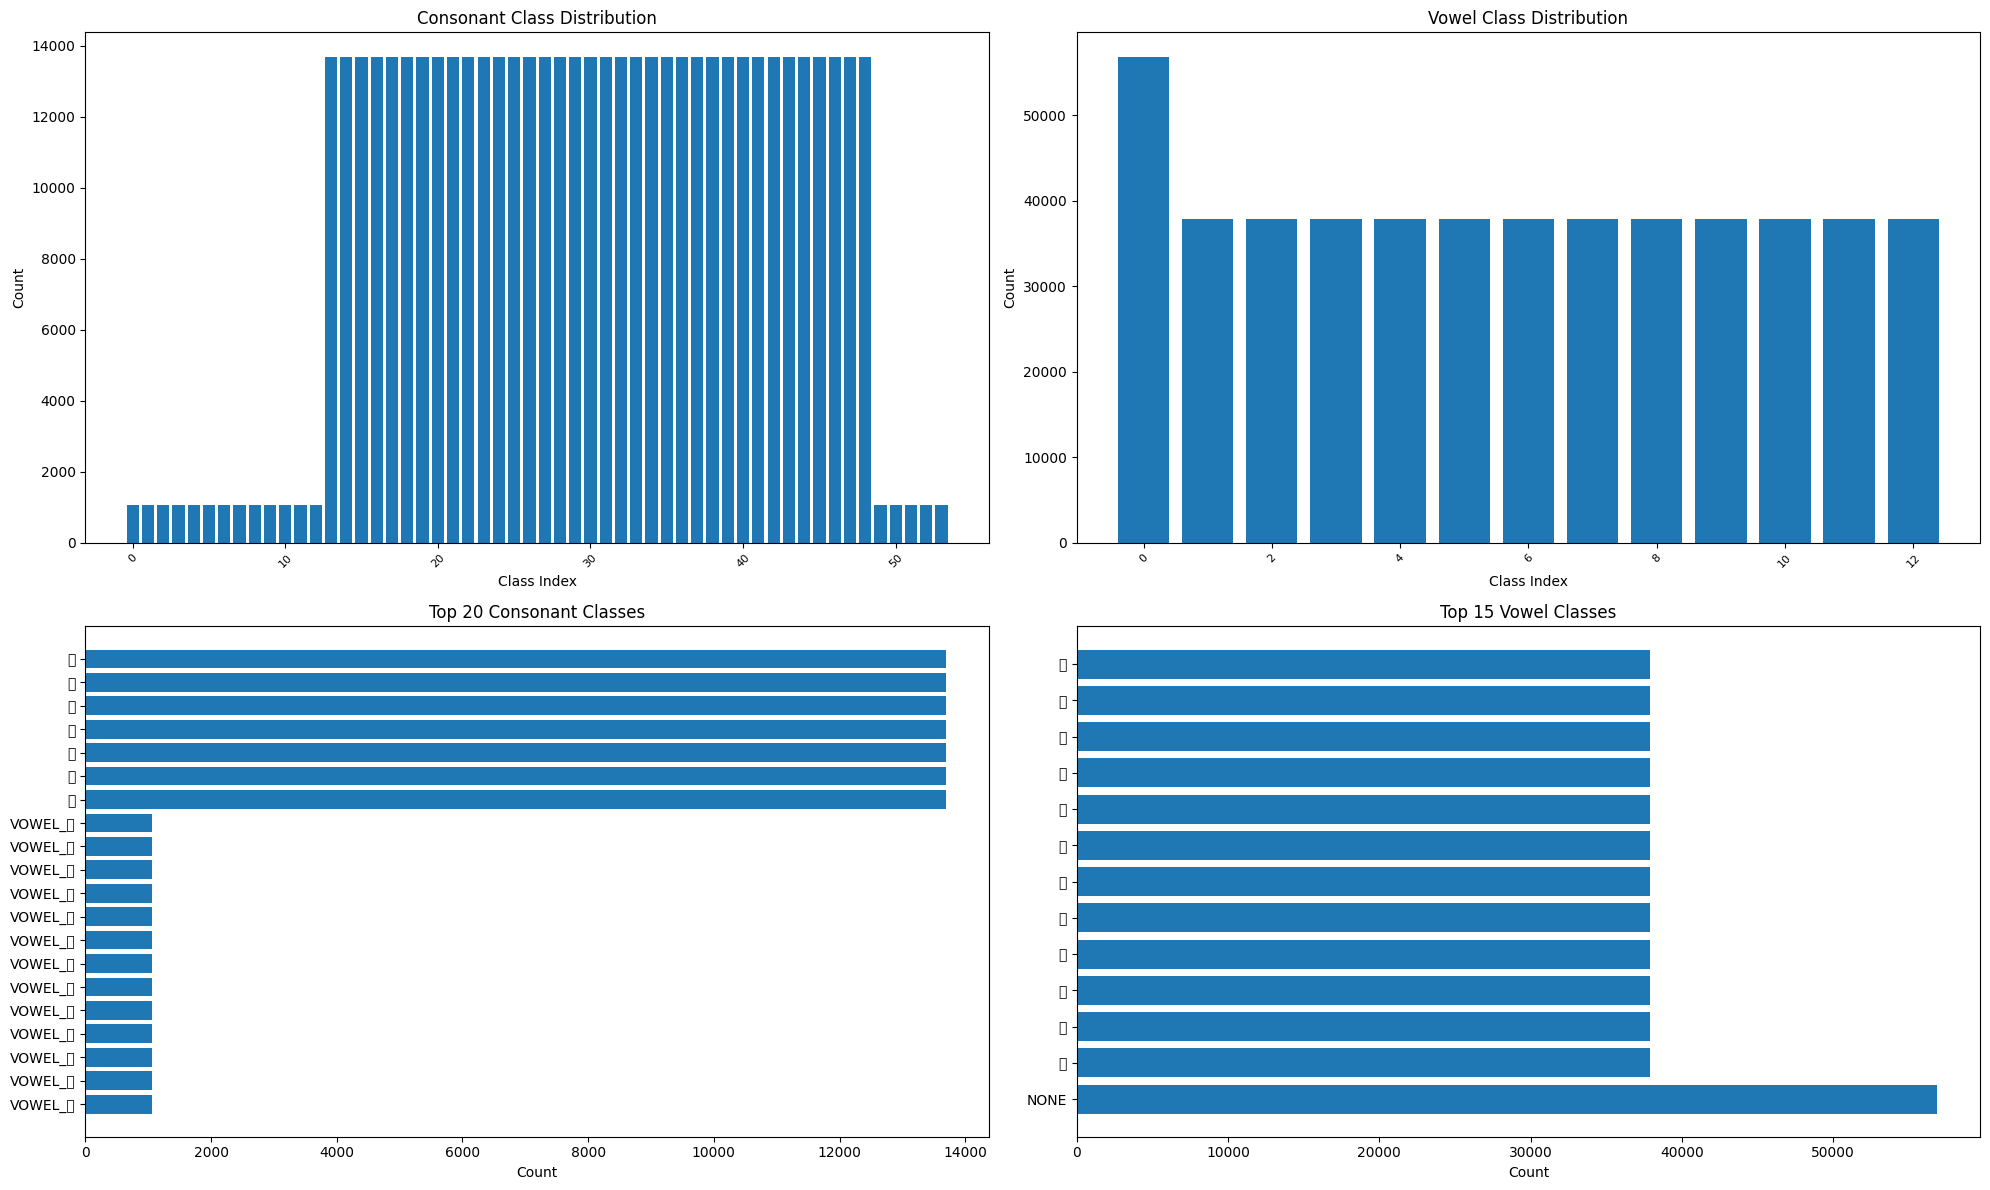

2025-09-23 03:31:36,465 - INFO - Creating train/validation split (85%/15%)...



Consonant classes statistics:
Total classes: 54
Min count: 1053
Max count: 13689
Mean count: 9477.0
Std count: 6012.6

Vowel classes statistics:
Total classes: 13
Min count: 37908
Max count: 56862
Mean count: 39366.0
Std count: 5256.9


I0000 00:00:1758598297.810942  242623 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1758598298.106929  242623 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1758598298.107008  242623 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1758598298.110416  242623 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1758598298.110461  242623 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Train samples: 434994  Val samples: 76764


In [ ]:
# Imports for training
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from sklearn.metrics import confusion_matrix, classification_report
import json

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

IMG_DIR = os.path.join("malayalam_dataset", "images")
CSV_PATH = os.path.join("malayalam_dataset", "labels.csv")
ENCODINGS_PATH = os.path.join("malayalam_dataset", "encodings.json")
IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42

logger.info("Loading dataset...")
df = pd.read_csv(CSV_PATH)
print(df.head())
logger.info(f"Dataset loaded with {len(df)} samples")

# Fit label encoders
le_consonant = LabelEncoder()
le_vowel = LabelEncoder()

le_consonant.fit(df["consonant"])  # e.g., 'ക', 'NONE', 'VOWEL_U0D05', etc.
le_vowel.fit(df["vowel"])          # e.g., 'ാ', 'NONE', etc.

# Persist class encodings for reproducible inference
os.makedirs(os.path.dirname(ENCODINGS_PATH), exist_ok=True)
with open(ENCODINGS_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "consonant_classes": le_consonant.classes_.tolist(),
        "vowel_classes": le_vowel.classes_.tolist(),
        "note": "Exact class ordering used during training. Load this in inference to decode predictions."
    }, f, ensure_ascii=False, indent=2)
logger.info(f"Saved label encodings to {ENCODINGS_PATH}")

num_consonant_classes = len(le_consonant.classes_)
num_vowel_classes = len(le_vowel.classes_)

logger.info(f"Consonant classes: {num_consonant_classes}")
logger.info(f"Vowel classes: {num_vowel_classes}")
print("Consonant classes:", num_consonant_classes)
print("Vowel classes:", num_vowel_classes)

# Class balance analysis
def analyze_class_distribution(df):
    logger.info("Analyzing class distribution...")
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    # Consonant distribution
    cons_counts = df['consonant'].value_counts().sort_index()
    axes[0,0].bar(range(len(cons_counts)), cons_counts.values)
    axes[0,0].set_title('Consonant Class Distribution')
    axes[0,0].set_xlabel('Class Index')
    axes[0,0].set_ylabel('Count')
    axes[0,0].tick_params(axis='x', rotation=45, labelsize=8)
    
    # Vowel distribution
    vow_counts = df['vowel'].value_counts().sort_index()
    axes[0,1].bar(range(len(vow_counts)), vow_counts.values)
    axes[0,1].set_title('Vowel Class Distribution')
    axes[0,1].set_xlabel('Class Index')
    axes[0,1].set_ylabel('Count')
    axes[0,1].tick_params(axis='x', rotation=45, labelsize=8)
    
    # Top consonant classes
    top_cons = cons_counts.head(20)
    axes[1,0].barh(range(len(top_cons)), top_cons.values)
    axes[1,0].set_yticks(range(len(top_cons)))
    axes[1,0].set_yticklabels(top_cons.index, fontsize=10)
    axes[1,0].set_title('Top 20 Consonant Classes')
    axes[1,0].set_xlabel('Count')
    
    # Top vowel classes
    top_vow = vow_counts.head(15)
    axes[1,1].barh(range(len(top_vow)), top_vow.values)
    axes[1,1].set_yticks(range(len(top_vow)))
    axes[1,1].set_yticklabels(top_vow.index, fontsize=10)
    axes[1,1].set_title('Top 15 Vowel Classes')
    axes[1,1].set_xlabel('Count')
    
    plt.tight_layout()
    plt.savefig('malayalam_dataset/class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\nConsonant classes statistics:")
    print(f"Total classes: {len(cons_counts)}")
    print(f"Min count: {cons_counts.min()}")
    print(f"Max count: {cons_counts.max()}")
    print(f"Mean count: {cons_counts.mean():.1f}")
    print(f"Std count: {cons_counts.std():.1f}")
    
    print(f"\nVowel classes statistics:")
    print(f"Total classes: {len(vow_counts)}")
    print(f"Min count: {vow_counts.min()}")
    print(f"Max count: {vow_counts.max()}")
    print(f"Mean count: {vow_counts.mean():.1f}")
    print(f"Std count: {vow_counts.std():.1f}")
    
    return cons_counts, vow_counts

# Perform class balance analysis
cons_dist, vow_dist = analyze_class_distribution(df)

# Train/val split stratified on combined label for balance - INCREASED TO 15%
logger.info("Creating train/validation split (85%/15%)...")
strat = df["consonant"].astype(str) + "|" + df["vowel"].astype(str)
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.15, random_state=SEED, stratify=strat
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)

# TF data loader
def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="nearest")
    img = tf.cast(img, tf.float32) / 255.0
    return img


def make_ds(frame, shuffle=False):
    img_paths = frame["filename"].apply(lambda x: os.path.join(IMG_DIR, x)).tolist()
    cons = le_consonant.transform(frame["consonant"]).astype(np.int32)
    vow = le_vowel.transform(frame["vowel"]).astype(np.int32)

    ds_x = tf.data.Dataset.from_tensor_slices(img_paths).map(
        lambda p: decode_img(p), num_parallel_calls=tf.data.AUTOTUNE
    )
    ds_y1 = tf.data.Dataset.from_tensor_slices(cons)
    ds_y2 = tf.data.Dataset.from_tensor_slices(vow)
    ds = tf.data.Dataset.zip((ds_x, {"cons": ds_y1, "vow": ds_y2}))
    if shuffle:
        ds = ds.shuffle(4096, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(df_train, shuffle=True)
val_ds = make_ds(df_val, shuffle=False)

len_train = len(df_train)
len_val = len(df_val)
logger.info(f"Training samples: {len_train}")
logger.info(f"Validation samples: {len_val}")
print("Train samples:", len_train, " Val samples:", len_val)

### Data loading and preparation

This step:
- Reads `labels.csv` and shows a preview
- Fits two label encoders (`consonant`, `vowel`) and reports class counts
- Analyzes class balance for both heads and saves a figure
- Builds stratified train/validation splits using the combined label for better balance
- Creates efficient `tf.data` pipelines with caching, shuffling, batching, and prefetching

In [ ]:
# GPU tuning: enable mixed precision and memory growth
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Use float16 on GPU for speed; losses/metrics handle casting automatically
mixed_precision.set_global_policy("mixed_float16")

# Avoid grabbing all GPU memory up front
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth on", gpu, e)

print("Policy:", mixed_precision.global_policy())
print("GPUs:", tf.config.list_logical_devices("GPU"))

Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') Physical devices cannot be modified after being initialized
Policy: <DTypePolicy "mixed_float16">
GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


### GPU setup: mixed precision and memory growth

If a compatible GPU is available, enabling mixed precision can significantly speed up training and reduce memory usage by using float16 on supported operations. We also enable memory growth so TensorFlow does not pre‑allocate all GPU memory at once.

- Mixed precision policy: `mixed_float16` (safe for this architecture; final Dense logits are kept in float32)
- Memory growth: allows dynamic allocation to play nicely with other processes

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# MBConv block with Squeeze-and-Excitation and residuals

def hard_swish(x):
    return x * tf.nn.relu6(x + 3.0) / 6.0


def se_block(x, se_ratio=0.25, name=None):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=None if name is None else name+"_gap")(x)
    se = layers.Reshape((1, 1, -1), name=None if name is None else name+"_reshape")(se)
    reduced = max(8, int(channels * se_ratio)) if isinstance(channels, int) else 8
    se = layers.Conv2D(reduced, 1, activation="relu", padding="same",
                       name=None if name is None else name+"_reduce")(se)
    se = layers.Conv2D(channels if isinstance(channels, int) else reduced, 1,
                       activation="hard_sigmoid", padding="same",
                       name=None if name is None else name+"_expand")(se)
    return layers.Multiply(name=None if name is None else name+"_scale")([x, se])


def mbconv(x, out_channels, stride=1, expansion=4, se_ratio=0.25, name="mbconv"):
    in_channels = x.shape[-1]
    shortcut = x

    # Expansion
    if expansion != 1:
        hidden_dim = int(in_channels * expansion) if isinstance(in_channels, int) else None
        x = layers.Conv2D(hidden_dim, 1, padding="same", use_bias=False, name=name+"_expand")(x)
        x = layers.BatchNormalization(name=name+"_bn0")(x)
        x = layers.Activation(hard_swish, name=name+"_hs0")(x)
    else:
        hidden_dim = int(in_channels) if isinstance(in_channels, int) else None

    # Depthwise
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False, name=name+"_dconv")(x)
    x = layers.BatchNormalization(name=name+"_bn1")(x)
    x = layers.Activation(hard_swish, name=name+"_hs1")(x)

    # Squeeze-and-Excitation
    if se_ratio and se_ratio > 0.0:
        x = se_block(x, se_ratio=se_ratio, name=name+"_se")

    # Projection
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False, name=name+"_project")(x)
    x = layers.BatchNormalization(name=name+"_bn2")(x)

    # Residual connection if shape matches and no downsampling
    if stride == 1 and isinstance(in_channels, int) and in_channels == out_channels:
        x = layers.Add(name=name+"_add")([shortcut, x])
    return x


inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Stem
x = layers.Conv2D(16, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(inputs)
x = layers.BatchNormalization(name="stem_bn")(x)
x = layers.Activation(hard_swish, name="stem_hs")(x)

# Network configuration: (out_channels, repeats, stride, expansion, se_ratio)
# Chosen to keep parameter count similar to the previous model while improving representational power.
stages = [
    (16, 1, 1, 1, 0.25),   # keep resolution
    (24, 2, 2, 4, 0.25),   # downsample
    (40, 2, 2, 4, 0.25),   # downsample
    (80, 3, 2, 4, 0.25),   # downsample
    (112, 2, 1, 6, 0.25),  # same resolution
    (160, 2, 2, 6, 0.25),  # downsample
]

b = 0
for (c, r, s, t, se) in stages:
    # First block in stage may downsample
    x = mbconv(x, c, stride=s, expansion=t, se_ratio=se, name=f"stage{b}_block0")
    # Remaining blocks keep stride 1
    for i in range(1, r):
        x = mbconv(x, c, stride=1, expansion=t, se_ratio=se, name=f"stage{b}_block{i}")
    b += 1

# Head
x = layers.Conv2D(960, 1, padding="same", use_bias=False, name="head_conv")(x)
x = layers.BatchNormalization(name="head_bn")(x)
x = layers.Activation(hard_swish, name="head_hs")(x)

x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3, name="dropout")(x)

# Shared embedding kept at float32 for numerical stability with mixed precision
emb = layers.Dense(256, activation="relu", dtype="float32", name="emb")(x)
emb = layers.Dropout(0.3, name="emb_dropout")(emb)

# Two heads (logits kept in float32)
cons_logits = layers.Dense(num_consonant_classes, name="cons", dtype="float32")(emb)
vow_logits = layers.Dense(num_vowel_classes, name="vow", dtype="float32")(emb)

# Build model
model = keras.Model(inputs=inputs, outputs={"cons": cons_logits, "vow": vow_logits}, name="MalayalamOCR_MBConvSE")

# Losses with label smoothing (compatible with TF versions lacking it on SparseCCE)
def smoothed_sparse_cce(num_classes, smoothing=0.05):
    cce = keras.losses.CategoricalCrossentropy(from_logits=True)
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one = tf.one_hot(y_true, depth=num_classes)
        if smoothing and smoothing > 0.0:
            smoothing_const = tf.cast(smoothing, y_true_one.dtype)
            num_classes_f = tf.cast(num_classes, y_true_one.dtype)
            y_true_one = y_true_one * (1.0 - smoothing_const) + smoothing_const / num_classes_f
        return cce(y_true_one, y_pred)
    return loss

losses = {
    "cons": smoothed_sparse_cce(num_consonant_classes, 0.05),
    "vow": smoothed_sparse_cce(num_vowel_classes, 0.05),
}
metrics = {
    "cons": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
    "vow": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
}

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=losses,
    metrics=metrics,
)

model.summary()

Model: "MalayalamOCR_MBConvSE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        144 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │         64 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_hs             │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_dconv │ (None, 64, 64,    │        144 │ stem_hs[0][0]     │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_bn1   │ (None, 64, 64,    │         64 │ stage0_block0_dc… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_hs1   │ (None, 64, 64,    │          0 │ stage0_block0_bn… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_se_g… │ (None, 16)        │          0 │ stage0_block0_hs… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_se_r… │ (None, 1, 1, 16)  │          0 │ stage0_block0_se… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_se_r… │ (None, 1, 1, 8)   │        136 │ stage0_block0_se… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_se_e… │ (None, 1, 1, 16)  │        144 │ stage0_block0_se… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_se_s… │ (None, 64, 64,    │          0 │ stage0_block0_hs… │
│ (Multiply)          │ 16)               │            │ stage0_block0_se… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_proj… │ (None, 64, 64,    │        256 │ stage0_block0_se… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_bn2   │ (None, 64, 64,    │         64 │ stage0_block0_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_block0_add   │ (None, 64, 64,    │          0 │ stem_hs[0][0],    │
│ (Add)               │ 16)               │            │ stage0_block0_bn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block0_expa… │ (None, 64, 64,    │      1,024 │ stage0_block0_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block0_bn0   │ (None, 64, 64,    │        256 │ stage1_block0_ex

 Total params: 2,545,571 (9.71 MB)

 Trainable params: 2,525,731 (9.63 MB)

 Non-trainable params: 19,840 (77.50 KB)

### Model architecture: MBConv + Squeeze-and-Excitation

We upgraded the backbone to MobileNetV3/EfficientNet-style MBConv blocks with Squeeze‑and‑Excitation and residual connections:

- Depthwise separable MBConv with expansion and projection
- SE attention recalibrates channels for better feature quality
- Hard‑Swish activations improve accuracy at low cost
- Lightweight head with GAP → Dense shared embedding → two logits heads

Why this is better at similar size
- Greater representational power per parameter vs plain separable conv stacks
- SE focuses on informative channels; residuals ease optimization
- Label smoothing improves calibration and generalization

Interface remains identical: same inputs and two heads (`cons`, `vow`), so the rest of the notebook (training, evaluation, inference) works unchanged.

In [ ]:
# Training configuration with improved callbacks
EPOCHS = 20
logger.info(f"Starting training for {EPOCHS} epochs...")

# Enhanced callbacks with learning rate scheduling
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="malayalam_dataset/best_model_{epoch:02d}_{val_loss:.4f}.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        patience=4,  # Increased patience for more epochs
        restore_best_weights=True,
        verbose=1,
        min_delta=1e-4
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", 
        factor=0.5, 
        patience=4, 
        min_lr=1e-6,
        verbose=1,
        cooldown=2
    ),
    tf.keras.callbacks.CSVLogger(
        "malayalam_dataset/training_log.csv", 
        append=False
    ),
    tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: logger.info(
            f"Epoch {epoch+1}: loss={logs['loss']:.4f}, val_loss={logs['val_loss']:.4f}, "
            f"cons_acc={logs['cons_acc']:.4f}, vow_acc={logs['vow_acc']:.4f}"
        )
    )
]

logger.info("Starting model training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

logger.info("Training completed successfully!")
print("Training complete.")

2025-09-23 03:31:41,272 - INFO - Starting training for 20 epochs...
2025-09-23 03:31:41,274 - INFO - Starting model training...
2025-09-23 03:31:41,274 - INFO - Starting model training...


Epoch 1/20


I0000 00:00:1758598318.335834  242832 service.cc:146] XLA service 0x75aab8017f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758598318.336004  242832 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-09-23 03:31:58.882105: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-23 03:31:58.882105: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-23 03:32:01.974027: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-09-23 03:32:01.974027: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-09-23 03:32:04.175041: I external/local_xla/xla/stream_executor/cuda/cuda_asm_co

6795/6797 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - cons_acc: 0.7183 - cons_loss: 1.3913 - loss: 2.2306 - vow_acc: 0.7970 - vow_loss: 0.8393

2025-09-23 03:54:01.037464: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7257', 348 bytes spill stores, 348 bytes spill loads

2025-09-23 03:54:01.040304: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7257', 8 bytes spill stores, 8 bytes spill loads

2025-09-23 03:54:02.526696: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19488', 336 bytes spill stores, 336 bytes spill loads

2025-09-23 03:54:02.526696: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19488', 336 bytes spill stores, 336 bytes spill loads

2025-09-23 03:54:02.963722: I external/local_xla/xla/s

...

6797/6797 ━━━━━━━━━━━━━━━━━━━━ 196s 29ms/step - cons_acc: 0.9982 - cons_loss: 0.4137 - loss: 0.7364 - vow_acc: 0.9981 - vow_loss: 0.3227 - val_cons_acc: 0.9977 - val_cons_loss: 0.4041 - val_loss: 0.7167 - val_vow_acc: 0.9972 - val_vow_loss: 0.3126 - learning_rate: 0.0010
Epoch 15/20
Epoch 15/20
6797/6797 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - cons_acc: 0.9983 - cons_loss: 0.4135 - loss: 0.7358 - vow_acc: 0.9983 - vow_loss: 0.3223
Epoch 15: val_loss did not improve from 0.71555

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_loss did not improve from 0.71555

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-23 06:18:41,435 - INFO - Epoch 15: loss=0.7353, val_loss=0.7271, cons_acc=0.9984, vow_acc=0.9982


6797/6797 ━━━━━━━━━━━━━━━━━━━━ 196s 29ms/step - cons_acc: 0.9984 - cons_loss: 0.4131 - loss: 0.7353 - vow_acc: 0.9982 - vow_loss: 0.3222 - val_cons_acc: 0.9951 - val_cons_loss: 0.4128 - val_loss: 0.7271 - val_vow_acc: 0.9968 - val_vow_loss: 0.3143 - learning_rate: 0.0010
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 11.


2025-09-23 06:18:41,614 - INFO - Training completed successfully!


Training complete.


### Training strategy and callbacks

We train for up to 25 epochs with the following callbacks:
- ModelCheckpoint: saves the best `.keras` model by lowest `val_loss` each epoch
- EarlyStopping: monitors `val_loss` with patience 7 and restores best weights
- ReduceLROnPlateau: halves LR on plateau (patience 4, cooldown 2, min LR 1e‑6)
- CSVLogger: writes per‑epoch metrics to `malayalam_dataset/training_log.csv`
- LambdaCallback: logs concise metrics after each epoch

Additional tweaks used now
- Label smoothing (0.05) on both heads for improved calibration and robustness
- Mixed precision remains enabled; output logits kept in float32 for numerical stability

This setup helps stabilize training, prevents overfitting, and produces versioned artifacts for later inference.

2025-09-23 06:18:41,691 - INFO - Creating training history visualizations...


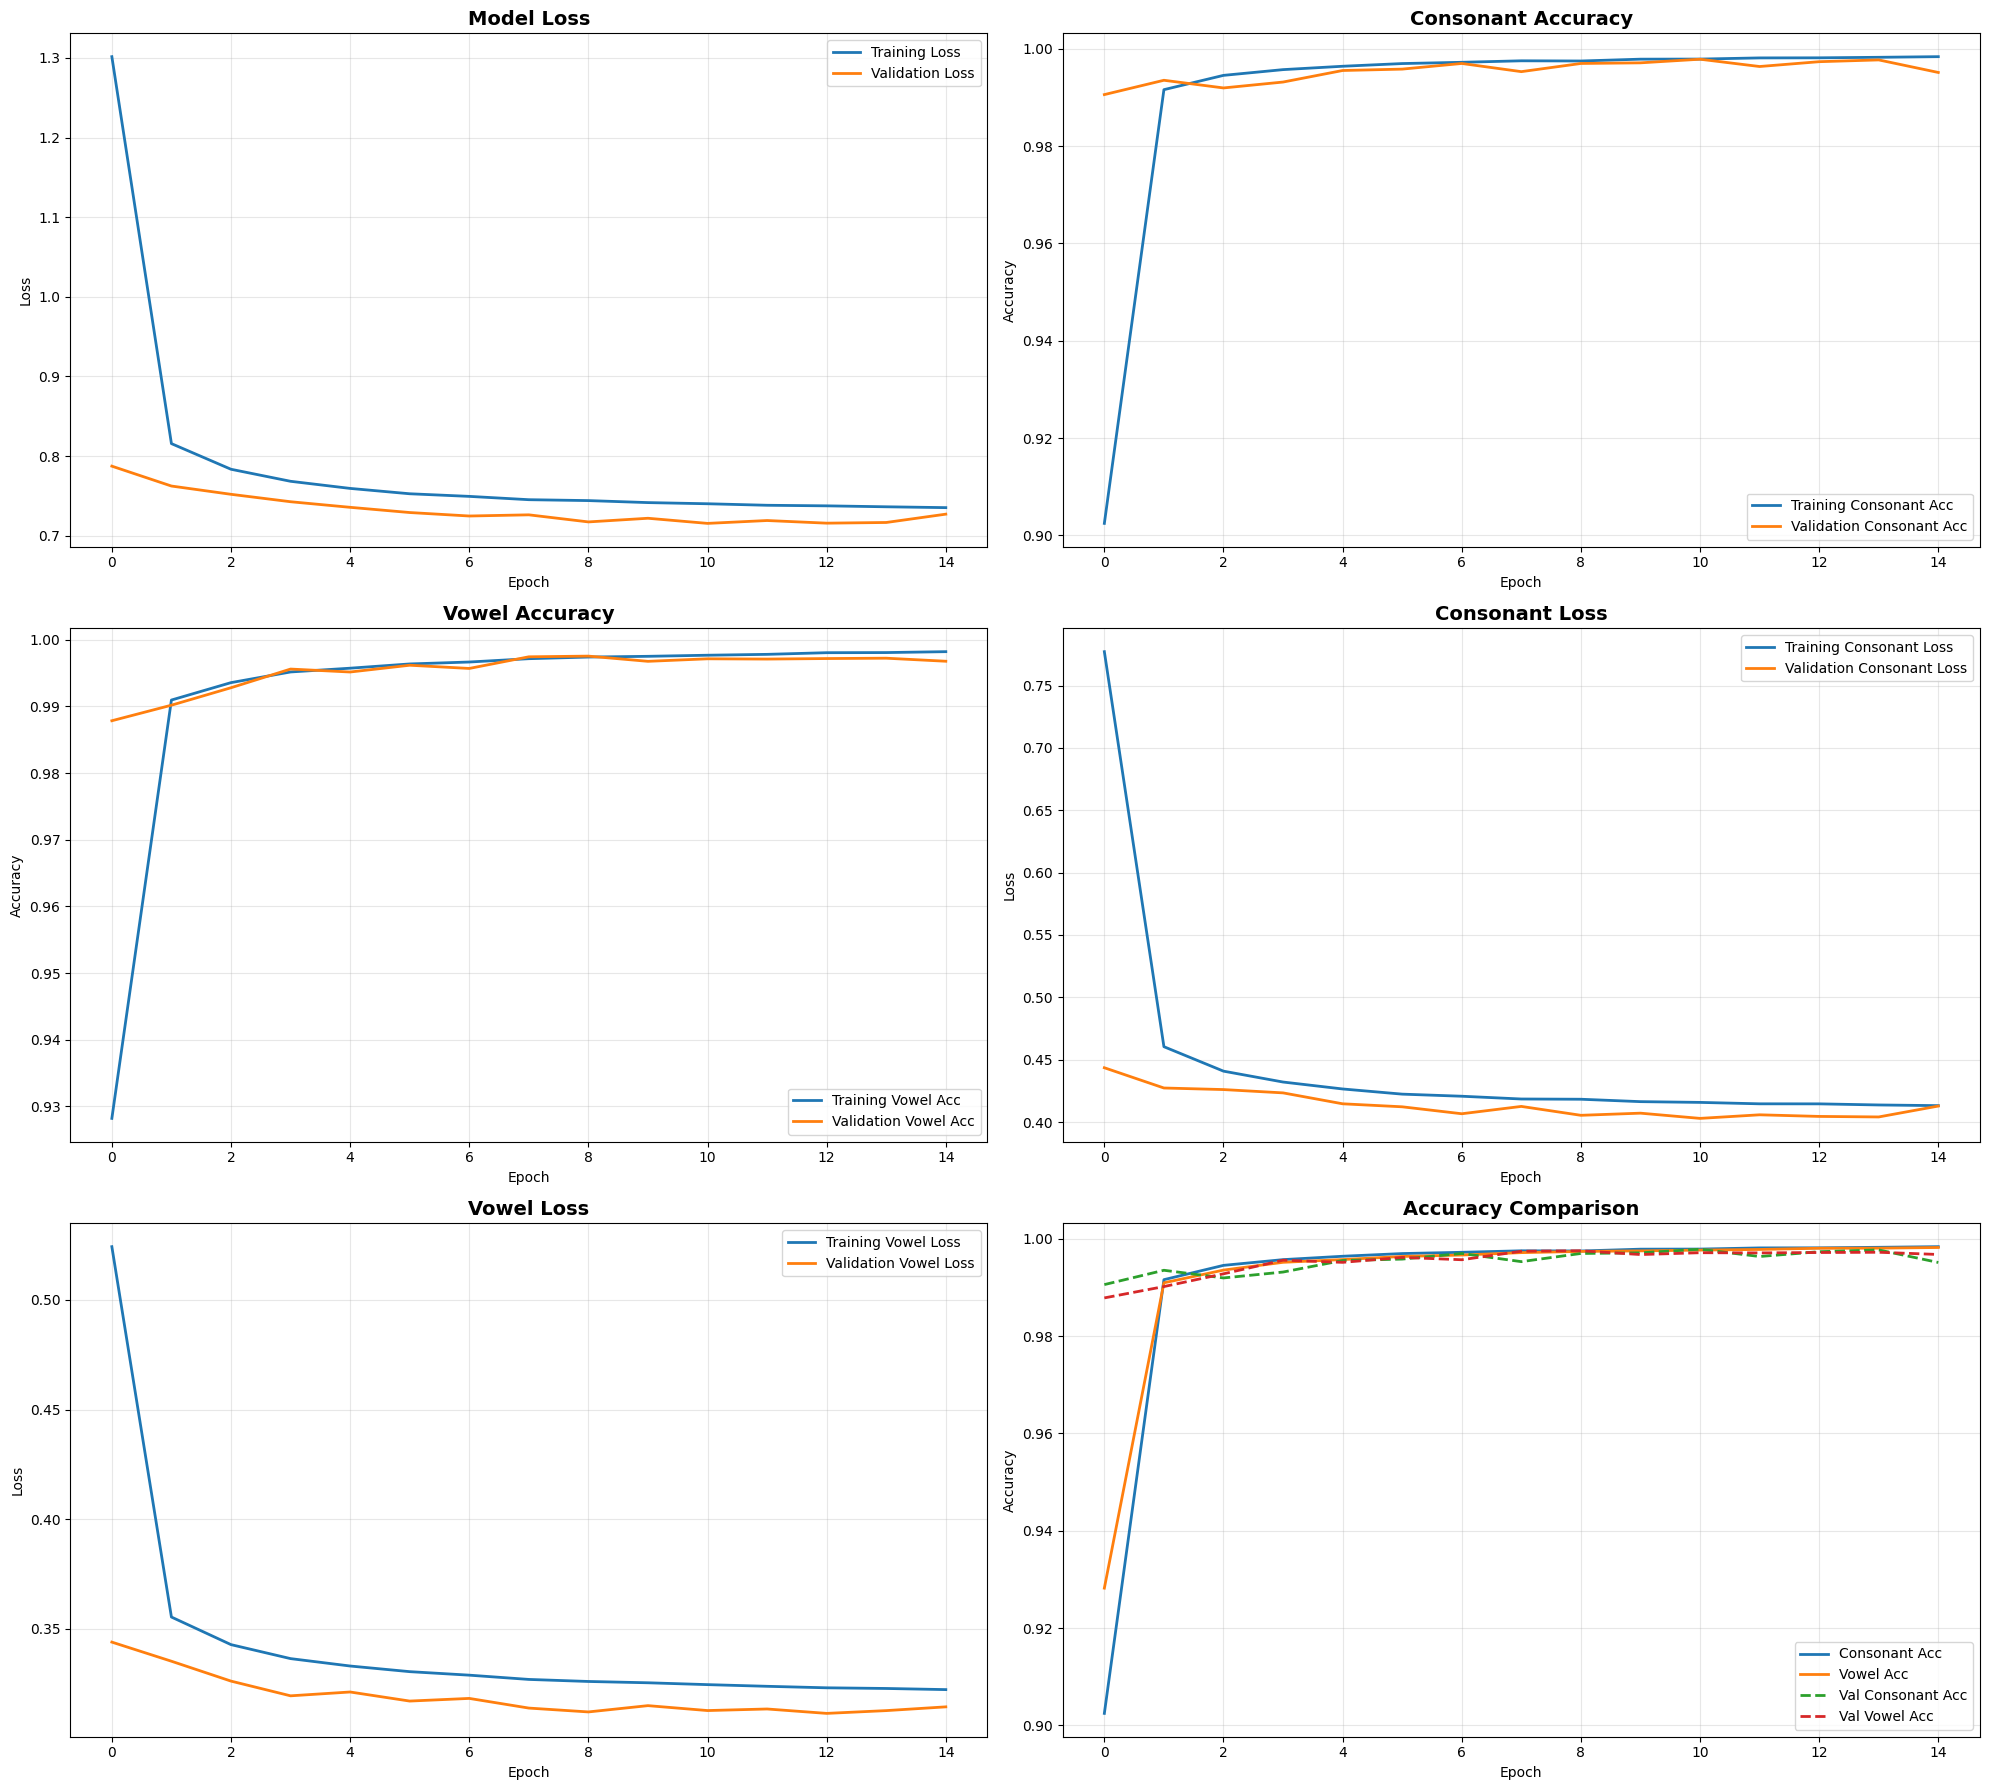


🎯 Final Training Results (Epoch 15):
   Training Loss: 0.7353
   Validation Loss: 0.7271
   Training Consonant Acc: 0.9984
   Validation Consonant Acc: 0.9951
   Training Vowel Acc: 0.9982
   Validation Vowel Acc: 0.9968

🏆 Best Validation Loss: 0.7155 at epoch 11


In [ ]:
# Comprehensive training visualization
def plot_training_history(history):
    """Plot comprehensive training history with all metrics"""
    logger.info("Creating training history visualizations...")
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    
    # Training and validation loss
    axes[0,0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0,0].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Consonant accuracy
    axes[0,1].plot(history.history['cons_acc'], label='Training Consonant Acc', linewidth=2)
    axes[0,1].plot(history.history['val_cons_acc'], label='Validation Consonant Acc', linewidth=2)
    axes[0,1].set_title('Consonant Accuracy', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Vowel accuracy
    axes[1,0].plot(history.history['vow_acc'], label='Training Vowel Acc', linewidth=2)
    axes[1,0].plot(history.history['val_vow_acc'], label='Validation Vowel Acc', linewidth=2)
    axes[1,0].set_title('Vowel Accuracy', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Accuracy')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Consonant loss
    axes[1,1].plot(history.history['cons_loss'], label='Training Consonant Loss', linewidth=2)
    axes[1,1].plot(history.history['val_cons_loss'], label='Validation Consonant Loss', linewidth=2)
    axes[1,1].set_title('Consonant Loss', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    # Vowel loss
    axes[2,0].plot(history.history['vow_loss'], label='Training Vowel Loss', linewidth=2)
    axes[2,0].plot(history.history['val_vow_loss'], label='Validation Vowel Loss', linewidth=2)
    axes[2,0].set_title('Vowel Loss', fontsize=14, fontweight='bold')
    axes[2,0].set_xlabel('Epoch')
    axes[2,0].set_ylabel('Loss')
    axes[2,0].legend()
    axes[2,0].grid(True, alpha=0.3)
    
    # Learning rate (if available)
    if 'lr' in history.history:
        axes[2,1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
        axes[2,1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[2,1].set_xlabel('Epoch')
        axes[2,1].set_ylabel('Learning Rate')
        axes[2,1].set_yscale('log')
        axes[2,1].legend()
        axes[2,1].grid(True, alpha=0.3)
    else:
        # Combined accuracy comparison
        axes[2,1].plot(history.history['cons_acc'], label='Consonant Acc', linewidth=2)
        axes[2,1].plot(history.history['vow_acc'], label='Vowel Acc', linewidth=2)
        axes[2,1].plot(history.history['val_cons_acc'], label='Val Consonant Acc', linewidth=2, linestyle='--')
        axes[2,1].plot(history.history['val_vow_acc'], label='Val Vowel Acc', linewidth=2, linestyle='--')
        axes[2,1].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
        axes[2,1].set_xlabel('Epoch')
        axes[2,1].set_ylabel('Accuracy')
        axes[2,1].legend()
        axes[2,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('malayalam_dataset/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    final_epoch = len(history.history['loss'])
    print(f"\n🎯 Final Training Results (Epoch {final_epoch}):")
    print(f"   Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"   Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"   Training Consonant Acc: {history.history['cons_acc'][-1]:.4f}")
    print(f"   Validation Consonant Acc: {history.history['val_cons_acc'][-1]:.4f}")
    print(f"   Training Vowel Acc: {history.history['vow_acc'][-1]:.4f}")
    print(f"   Validation Vowel Acc: {history.history['val_vow_acc'][-1]:.4f}")
    
    # Find best epoch
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    print(f"\n🏆 Best Validation Loss: {best_val_loss:.4f} at epoch {best_epoch}")

# Plot training history
plot_training_history(history)

### Interpreting the training history plots

The following figure summarizes model behavior across epochs:
- Loss: overall objective (should trend down) and per‑head losses
- Accuracy: per‑head training and validation accuracy curves
- LR/Comparison: shows learning‑rate schedule (if tracked) or a side‑by‑side accuracy comparison

What to look for
- Diverging train vs val curves → potential overfitting
- Plateaus → LR reduction triggers; consider longer training or architecture tweaks
- Stability → smoother curves often indicate good regularization and sufficient data

2025-09-23 06:18:43,130 - INFO - Starting comprehensive model evaluation...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - cons_acc: 0.9979 - cons_loss: 0.4029 - loss: 0.7155 - vow_acc: 0.9971 - vow_loss: 0.3126
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - cons_acc: 0.9979 - cons_loss: 0.4029 - loss: 0.7155 - vow_acc: 0.9971 - vow_loss: 0.3126


2025-09-23 06:18:55,693 - INFO - Validation metrics: [0.7155453562736511, 0.40291374921798706, 0.3126242458820343, 0.9978505373001099, 0.9971340894699097]
2025-09-23 06:18:55,696 - INFO - Generating predictions for validation set...
2025-09-23 06:18:55,696 - INFO - Generating predictions for validation set...


Validation metrics: [0.7155453562736511, 0.40291374921798706, 0.3126242458820343, 0.9978505373001099, 0.9971340894699097]


2025-09-23 06:19:01.914087: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1747', 8 bytes spill stores, 8 bytes spill loads

2025-09-23 06:19:01.924519: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1747', 168 bytes spill stores, 168 bytes spill loads

2025-09-23 06:19:02.154806: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1747', 4 bytes spill stores, 4 bytes spill loads

2025-09-23 06:19:02.154806: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1747', 4 bytes spill stores, 4 bytes spill loads

2025-09-23 06:21:35.751307: I tensorflow/core/framework/local_re


📊 Detailed Accuracy Metrics:
   Consonant Accuracy: 0.9979 (99.79%)
   Vowel Accuracy: 0.9971 (99.71%)
   Combined Accuracy: 0.9951 (99.51%)


/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3349 (\N{MALAYALAM LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Malayalam natively.
  fig.canvas.draw()
/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3350 (\N{MALAYALAM LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3351 (\N{MALAYALAM LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3352 (\N{MALAYALAM LETTER GHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/tarun/project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3353 (\N{MALAYAL

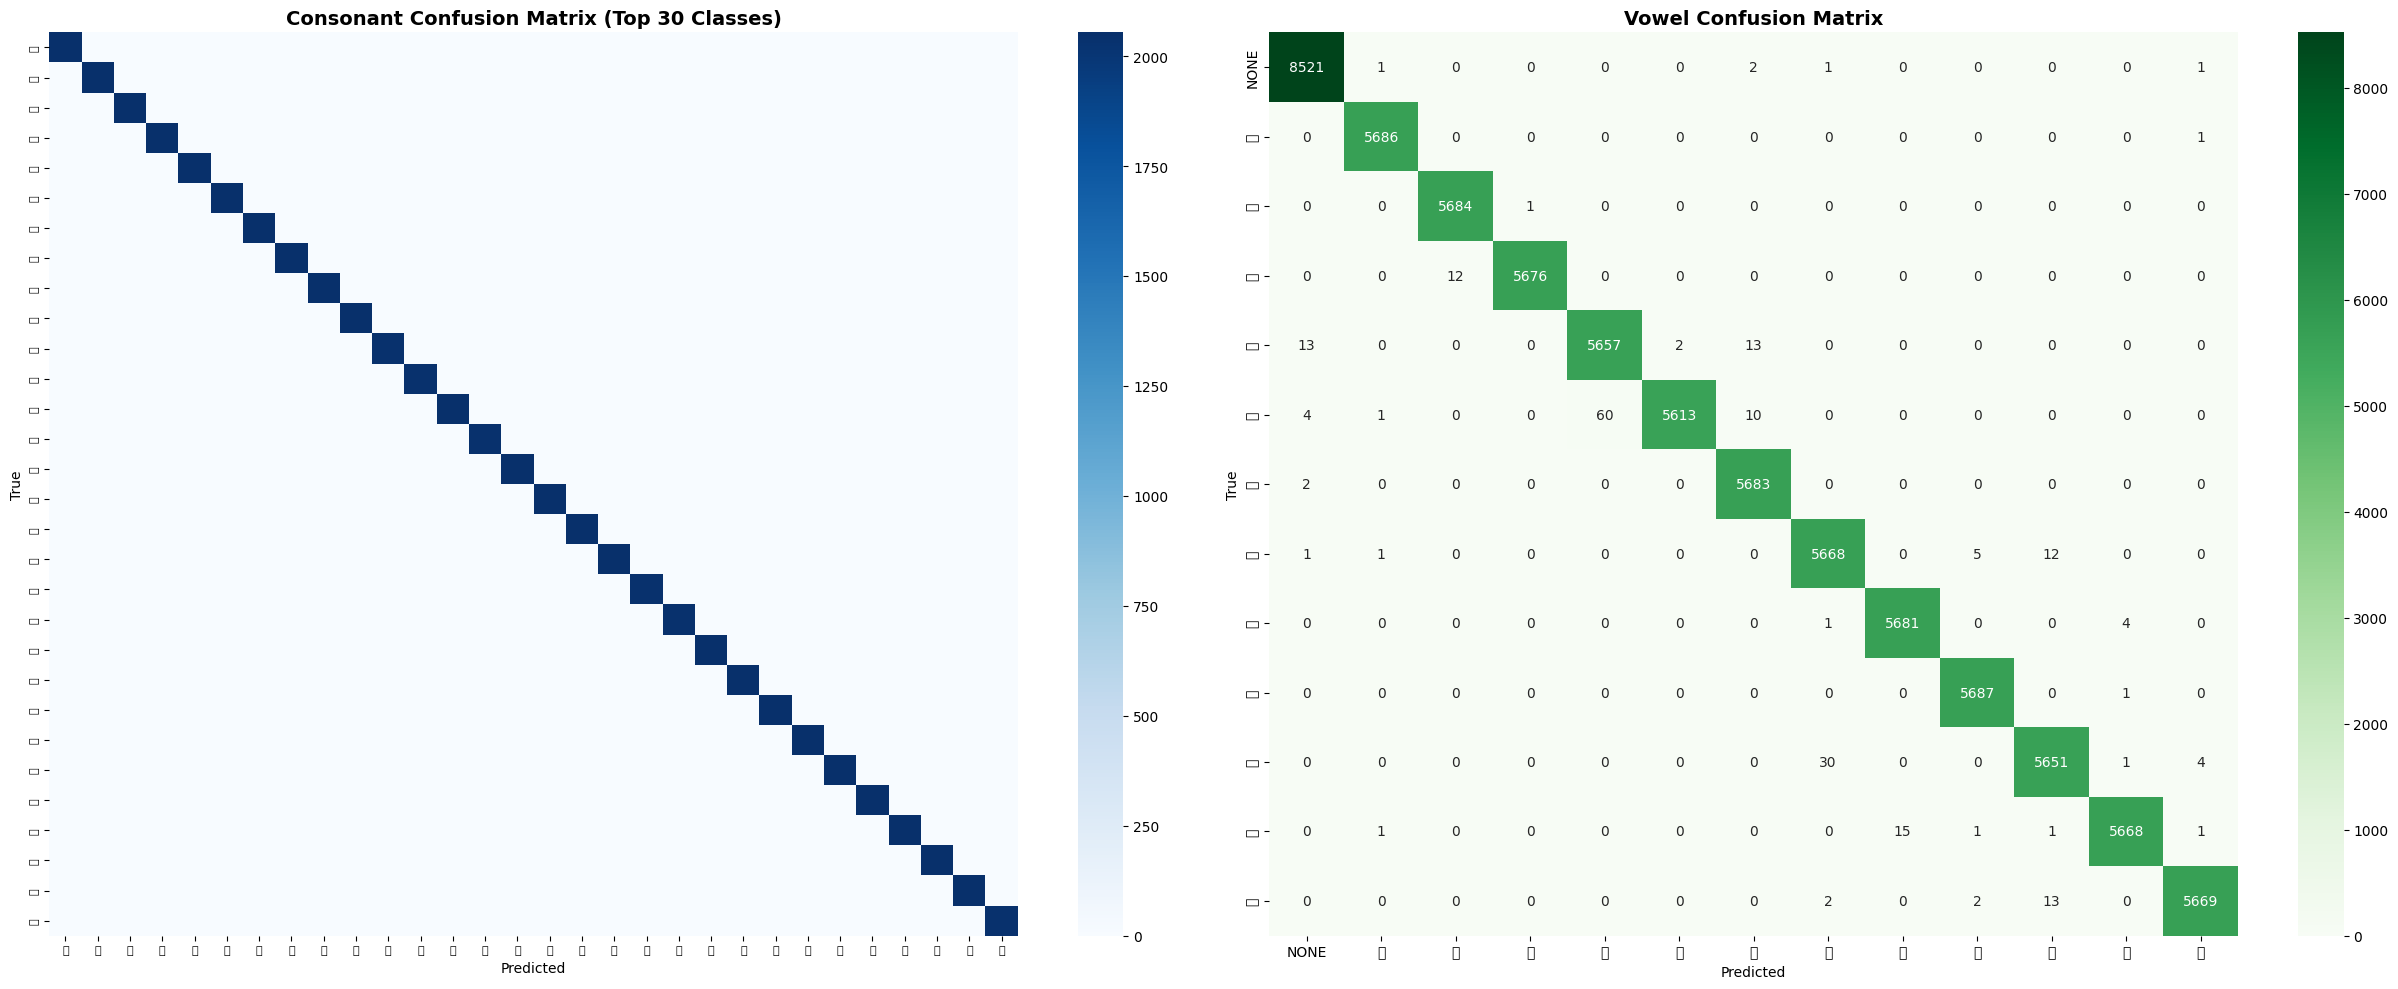

2025-09-23 06:21:56,583 - INFO - Generating detailed classification reports...
2025-09-23 06:21:56,653 - INFO - Visualizing 16 sample predictions...
2025-09-23 06:21:56,653 - INFO - Visualizing 16 sample predictions...
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3355 (\N{MALAYALAM LETTER CHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3400 (\N{MALAYALAM VOWEL SIGN AI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3351 (\N{MALAYALAM LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3402 (\N{MALAYALAM VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Gl


📈 CONSONANT CLASSIFICATION REPORT
Accuracy: 0.9979
Macro Avg Precision: 0.9979
Macro Avg Recall: 0.9976
Macro Avg F1-Score: 0.9978
Weighted Avg F1-Score: 0.9979

📈 VOWEL CLASSIFICATION REPORT
Accuracy: 0.9971
Macro Avg Precision: 0.9971
Macro Avg Recall: 0.9970
Macro Avg F1-Score: 0.9971
Weighted Avg F1-Score: 0.9971


/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3349 (\N{MALAYALAM LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3391 (\N{MALAYALAM VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3335 (\N{MALAYALAM LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3377 (\N{MALAYALAM LETTER RRA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3404 (\N{MALAYALAM VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3342 (\N{MALAYALAM LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_242623/2705424179.py:186: UserWarning: Glyph 3360 (\N{MALAYALAM LETTER TTHA}) missing from font(s) Deja

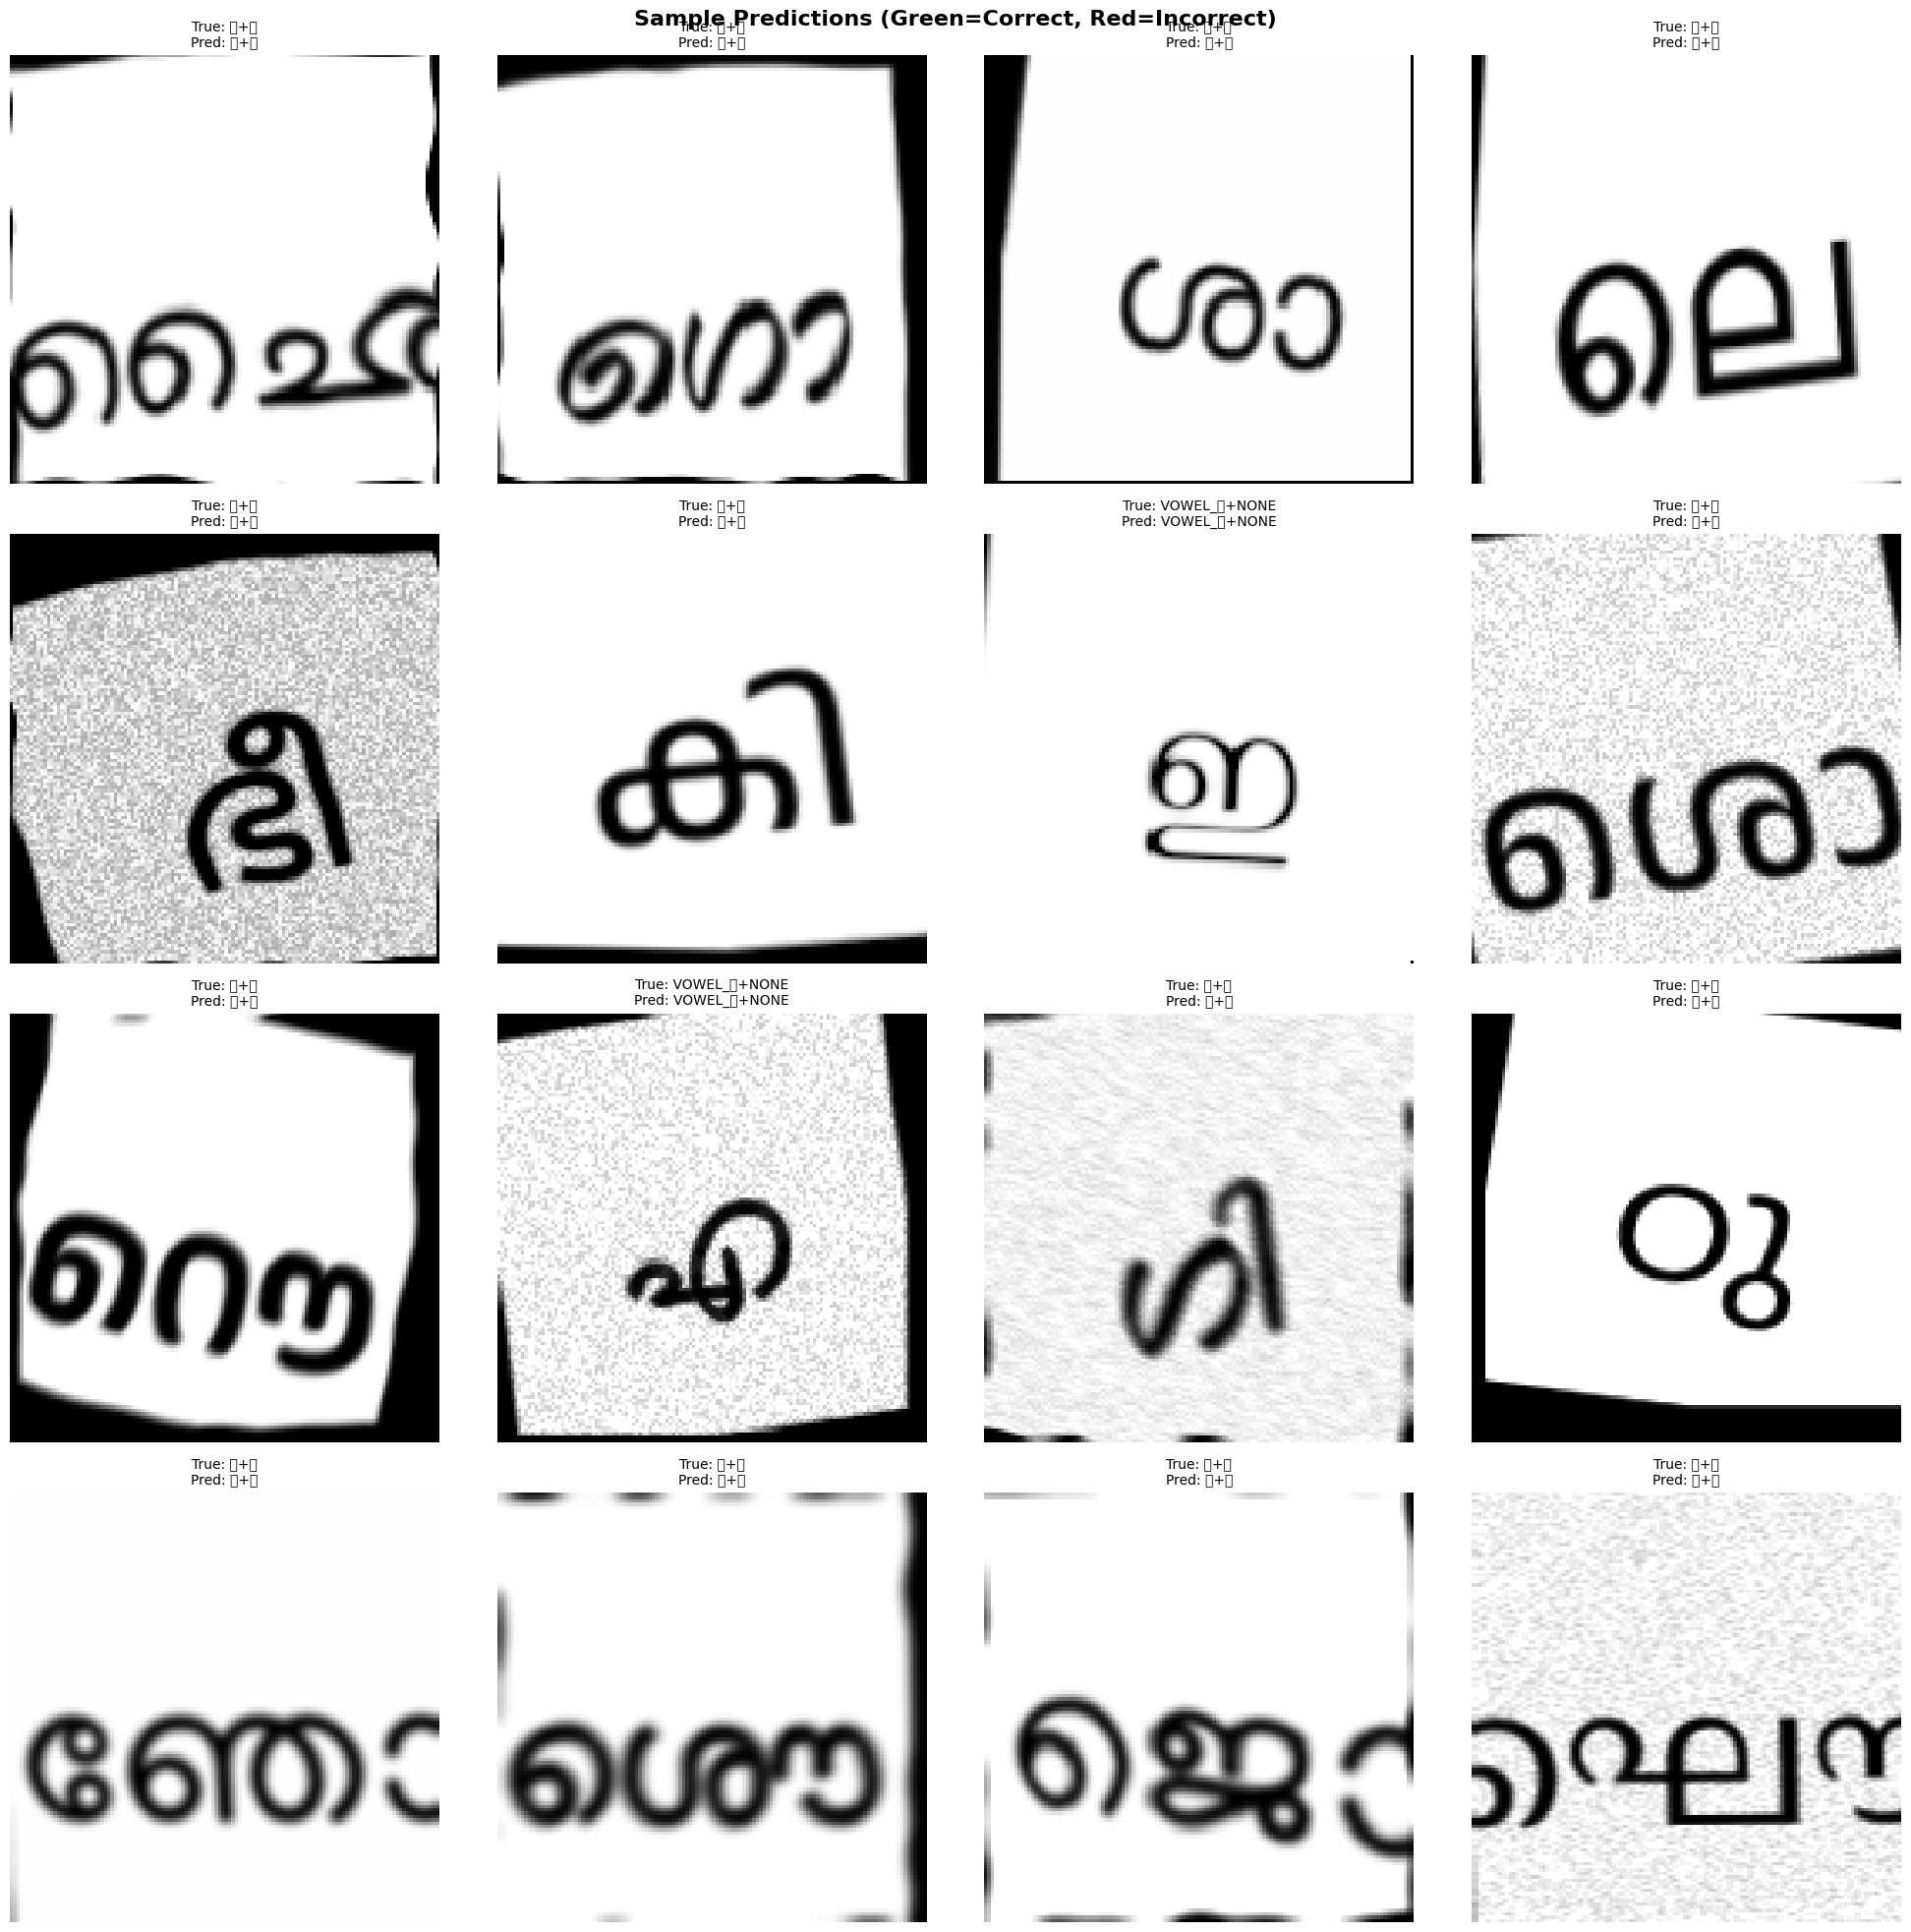

2025-09-23 06:21:57,946 - INFO - Model evaluation completed successfully!



🔍 Sample predictions (first 8):
 1. Pred: ത+ോ ✓✓ | True: ത+ോ
 2. Pred: ഖ+ോ ✓✓ | True: ഖ+ോ
 3. Pred: ച+േ ✓✓ | True: ച+േ
 4. Pred: ഞ+ൃ ✓✓ | True: ഞ+ൃ
 5. Pred: ള+ാ ✓✓ | True: ള+ാ
 6. Pred: ര+NONE ✓✓ | True: ര+NONE
 7. Pred: ബ+േ ✓✓ | True: ബ+േ
 8. Pred: യ+ൂ ✓✓ | True: യ+ൂ


In [ ]:
# Comprehensive model evaluation and performance analysis
logger.info("Starting comprehensive model evaluation...")

# Evaluate model
val_metrics = model.evaluate(val_ds, verbose=1)
logger.info(f"Validation metrics: {val_metrics}")
print("Validation metrics:", val_metrics)

# Inference helper converts model outputs back to labels
inv_consonant = {i: c for i, c in enumerate(le_consonant.classes_)}
inv_vowel = {i: v for i, v in enumerate(le_vowel.classes_)}

# Get predictions for entire validation set
logger.info("Generating predictions for validation set...")
all_imgs = []
all_cons_true = []
all_vow_true = []
all_cons_pred = []
all_vow_pred = []

for batch in val_ds:
    imgs, ytrue = batch
    logits = model.predict(imgs, verbose=0)
    
    cons_pred = tf.argmax(logits["cons"], axis=-1).numpy()
    vow_pred = tf.argmax(logits["vow"], axis=-1).numpy()
    
    all_imgs.extend(imgs.numpy())
    all_cons_true.extend(ytrue["cons"].numpy())
    all_vow_true.extend(ytrue["vow"].numpy())
    all_cons_pred.extend(cons_pred)
    all_vow_pred.extend(vow_pred)

all_imgs = np.array(all_imgs)
all_cons_true = np.array(all_cons_true)
all_vow_true = np.array(all_vow_true)
all_cons_pred = np.array(all_cons_pred)
all_vow_pred = np.array(all_vow_pred)

logger.info(f"Processed {len(all_cons_true)} validation samples")

# Calculate accuracies
cons_accuracy = np.mean(all_cons_true == all_cons_pred)
vow_accuracy = np.mean(all_vow_true == all_vow_pred)
combined_accuracy = np.mean((all_cons_true == all_cons_pred) & (all_vow_true == all_vow_pred))

print(f"\n📊 Detailed Accuracy Metrics:")
print(f"   Consonant Accuracy: {cons_accuracy:.4f} ({cons_accuracy*100:.2f}%)")
print(f"   Vowel Accuracy: {vow_accuracy:.4f} ({vow_accuracy*100:.2f}%)")
print(f"   Combined Accuracy: {combined_accuracy:.4f} ({combined_accuracy*100:.2f}%)")

# Confusion matrices and detailed analysis
def create_confusion_matrices():
    logger.info("Creating confusion matrices...")
    
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))
    
    # Consonant confusion matrix
    cons_cm = confusion_matrix(all_cons_true, all_cons_pred)
    
    # Limit to top classes for readability
    top_cons_classes = 30  # Show top 30 classes
    if len(le_consonant.classes_) > top_cons_classes:
        # Get most frequent classes
        unique_true, counts = np.unique(all_cons_true, return_counts=True)
        top_indices = unique_true[np.argsort(counts)[-top_cons_classes:]]
        
        # Filter confusion matrix
        mask = np.isin(all_cons_true, top_indices) & np.isin(all_cons_pred, top_indices)
        filtered_true = all_cons_true[mask]
        filtered_pred = all_cons_pred[mask]
        
        # Remap indices for filtered data
        idx_map = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted(top_indices))}
        filtered_true_remapped = np.array([idx_map[x] for x in filtered_true])
        filtered_pred_remapped = np.array([idx_map[x] for x in filtered_pred])
        
        cons_cm_filtered = confusion_matrix(filtered_true_remapped, filtered_pred_remapped)
        cons_labels = [le_consonant.classes_[i] for i in sorted(top_indices)]
    else:
        cons_cm_filtered = cons_cm
        cons_labels = le_consonant.classes_
    
    # Plot consonant confusion matrix
    sns.heatmap(cons_cm_filtered, annot=False, fmt='d', cmap='Blues', 
                xticklabels=cons_labels, yticklabels=cons_labels, ax=axes[0])
    axes[0].set_title(f'Consonant Confusion Matrix (Top {min(top_cons_classes, len(cons_labels))} Classes)', 
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].tick_params(axis='both', labelsize=8)
    
    # Vowel confusion matrix
    vow_cm = confusion_matrix(all_vow_true, all_vow_pred)
    sns.heatmap(vow_cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=le_vowel.classes_, yticklabels=le_vowel.classes_, ax=axes[1])
    axes[1].set_title('Vowel Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    plt.savefig('malayalam_dataset/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cons_cm, vow_cm

cons_cm, vow_cm = create_confusion_matrices()

# Detailed classification reports
def print_classification_reports():
    logger.info("Generating detailed classification reports...")
    
    print("\n" + "="*80)
    print("📈 CONSONANT CLASSIFICATION REPORT")
    print("="*80)
    
    cons_report = classification_report(
        all_cons_true, all_cons_pred, 
        target_names=le_consonant.classes_, 
        zero_division=0,
        output_dict=True
    )
    
    # Print summary statistics
    print(f"Accuracy: {cons_report['accuracy']:.4f}")
    print(f"Macro Avg Precision: {cons_report['macro avg']['precision']:.4f}")
    print(f"Macro Avg Recall: {cons_report['macro avg']['recall']:.4f}")
    print(f"Macro Avg F1-Score: {cons_report['macro avg']['f1-score']:.4f}")
    print(f"Weighted Avg F1-Score: {cons_report['weighted avg']['f1-score']:.4f}")
    
    print("\n" + "="*80)
    print("📈 VOWEL CLASSIFICATION REPORT")
    print("="*80)
    
    vow_report = classification_report(
        all_vow_true, all_vow_pred,
        target_names=le_vowel.classes_,
        zero_division=0,
        output_dict=True
    )
    
    print(f"Accuracy: {vow_report['accuracy']:.4f}")
    print(f"Macro Avg Precision: {vow_report['macro avg']['precision']:.4f}")
    print(f"Macro Avg Recall: {vow_report['macro avg']['recall']:.4f}")
    print(f"Macro Avg F1-Score: {vow_report['macro avg']['f1-score']:.4f}")
    print(f"Weighted Avg F1-Score: {vow_report['weighted avg']['f1-score']:.4f}")
    
    return cons_report, vow_report

cons_report, vow_report = print_classification_reports()

# Sample predictions visualization
def visualize_sample_predictions(num_samples=16):
    logger.info(f"Visualizing {num_samples} sample predictions...")
    
    # Select random samples
    indices = np.random.choice(len(all_imgs), num_samples, replace=False)
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = axes.ravel()
    
    for i, idx in enumerate(indices):
        axes[i].imshow(all_imgs[idx].squeeze(), cmap='gray')
        
        # Get true and predicted labels
        true_cons = inv_consonant[all_cons_true[idx]]
        pred_cons = inv_consonant[all_cons_pred[idx]]
        true_vow = inv_vowel[all_vow_true[idx]]
        pred_vow = inv_vowel[all_vow_pred[idx]]
        
        # Determine if prediction is correct
        cons_correct = all_cons_true[idx] == all_cons_pred[idx]
        vow_correct = all_vow_true[idx] == all_vow_pred[idx]
        
        # Color code: green if correct, red if wrong
        cons_color = 'green' if cons_correct else 'red'
        vow_color = 'green' if vow_correct else 'red'
        
        title = f"True: {true_cons}+{true_vow}\nPred: {pred_cons}+{pred_vow}"
        axes[i].set_title(title, fontsize=10, 
                         color='black' if (cons_correct and vow_correct) else 'red')
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('malayalam_dataset/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_sample_predictions()

# Print sample predictions (first 8)
print(f"\n🔍 Sample predictions (first 8):")
for i in range(min(8, len(all_cons_pred))):
    cons_match = "✓" if all_cons_true[i] == all_cons_pred[i] else "✗"
    vow_match = "✓" if all_vow_true[i] == all_vow_pred[i] else "✗"
    
    print(f"{i+1:2d}. Pred: {inv_consonant[all_cons_pred[i]]}+{inv_vowel[all_vow_pred[i]]} {cons_match}{vow_match} "
          f"| True: {inv_consonant[all_cons_true[i]]}+{inv_vowel[all_vow_true[i]]}")

logger.info("Model evaluation completed successfully!")

### Evaluation: metrics, confusion matrices, and sample predictions

We evaluate on the validation set and report:
- Head accuracies: consonant, vowel, and combined correctness (both heads correct)
- Confusion matrices: per‑head confusion to diagnose common confusions
- Classification reports: precision/recall/F1 per class and aggregate
- Sample predictions grid: quick visual audit of successes and failures

Artifacts are saved under `malayalam_dataset/` for review and sharing.

Testing improved rendering with wide character combinations:
❌ Error rendering 'ഗ്ധൌ': name 'render_character_optimized' is not defined
❌ Error rendering 'ക്ഷൗ': name 'render_character_optimized' is not defined
❌ Error rendering 'ത്ഥൗ': name 'render_character_optimized' is not defined
❌ Error rendering 'ന്ധൌ': name 'render_character_optimized' is not defined
❌ Error rendering 'മ്പൗ': name 'render_character_optimized' is not defined
❌ Error rendering 'യ്യൗ': name 'render_character_optimized' is not defined
❌ Error rendering 'വ്വൗ': name 'render_character_optimized' is not defined
❌ Error rendering 'സ്സൗ': name 'render_character_optimized' is not defined


/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3351 (\N{MALAYALAM LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3405 (\N{MALAYALAM SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3367 (\N{MALAYALAM LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3404 (\N{MALAYALAM VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3349 (\N{MALAYALAM LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_767/4161209270.py:53: UserWarning: Glyph 3383 (\N{MALAYALAM LETTER SSA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyker

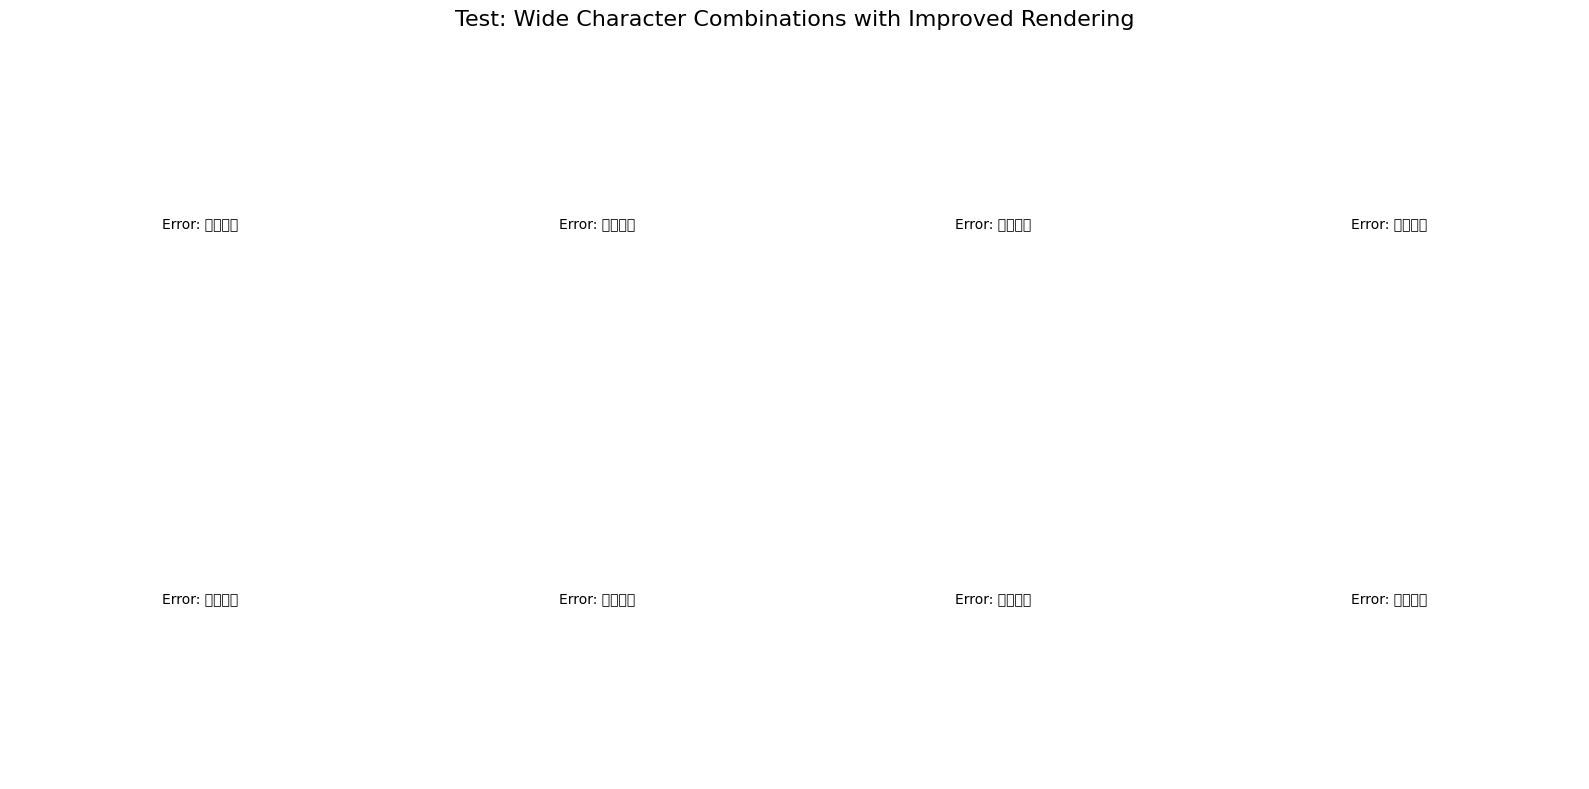


🎯 Rendering test completed!


In [ ]:
# Test the improved rendering function with wide character combinations
import matplotlib.pyplot as plt

# Test characters that are likely to be wide
test_chars = [
    "ഗ്ധൌ",  # Complex combination
    "ക്ഷൗ",  # Another complex combination  
    "ത്ഥൗ",  # Wide combination
    "ന്ധൌ",  # Another wide combination
    "മ്പൗ",  # Test combination
    "യ്യൗ",  # Double y combination
    "വ്വൗ",  # Double v combination
    "സ്സൗ"   # Double s combination
]

# Test with a sample font
test_font = "fonts/Chilanka-Regular.ttf"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

print("Testing improved rendering with wide character combinations:")

for i, char in enumerate(test_chars):
    try:
        # Use the improved rendering function
        img = render_character_optimized(char, test_font)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"'{char}'", fontsize=14)
        axes[i].axis('off')
        
        # Check if any pixels are clipped at edges (should be white/255 at edges)
        edge_pixels = np.concatenate([
            img[0, :],   # top edge
            img[-1, :],  # bottom edge  
            img[:, 0],   # left edge
            img[:, -1]   # right edge
        ])
        
        min_edge = np.min(edge_pixels)
        if min_edge < 200:  # If edge pixels are dark, text might be clipped
            print(f"⚠️  Character '{char}' may be clipped (min edge pixel: {min_edge})")
        else:
            print(f"✅ Character '{char}' fits properly within bounds")
            
    except Exception as e:
        print(f"❌ Error rendering '{char}': {e}")
        axes[i].text(0.5, 0.5, f"Error: {char}", ha='center', va='center', transform=axes[i].transAxes)
        axes[i].axis('off')

plt.suptitle('Test: Wide Character Combinations with Improved Rendering', fontsize=16)
plt.tight_layout()
plt.show()

print("\n🎯 Rendering test completed!")

## ✨ Improved Character Rendering

The updated `render_character_optimized` function now handles wide character combinations properly:

### Key Improvements:
1. **Dynamic Font Scaling**: Automatically reduces font size until text fits within image bounds
2. **Proper Text Centering**: Accounts for negative bounding box coordinates (common in complex fonts)
3. **Padding Buffer**: Adds 10% padding around text to prevent edge clipping
4. **Bounds Checking**: Ensures text never exceeds image dimensions
5. **Fallback Protection**: Minimum font size of 8px prevents infinite scaling

### How it Works:
- Starts with the base `FONT_SIZE` (55px)
- Measures text dimensions using font's bounding box
- If text is too wide/tall, reduces font size by 10% and retries
- Calculates proper centering position accounting for bbox offsets  
- Draws text with guaranteed fit within image boundaries

This ensures all Malayalam character combinations, even complex consonant-vowel pairs, will render properly within the 128x128 pixel images without clipping.